In [ ]:
import copy
import cv2
from pathlib import Path
import os
from PIL import Image
import json
import numpy as np
import torch


dataset_path = Path("dataset/crop")
image_paths = dataset_path.glob("*.png")
image_paths_10 = [img for img in image_paths][:10]


dataset_json_path = Path("dataset/json_labels")



: 

In [3]:
def get_bbox_xyxy(image_path):
    json_path = dataset_json_path / f"{image_path.stem}.json" 
    print(json_path)

    with open(json_path, "r") as file:
        annontation = json.load(file)

    bbox_xyxy = annontation['annotations'][0]['bbox_xyxy']
    down_left = (int(bbox_xyxy[0]), int(bbox_xyxy[1]))
    up_right = (int(bbox_xyxy[2]), int(bbox_xyxy[3]))
    return [down_left, up_right]


def draw_rectangle_on_image(image_src, down_left, up_right):
    image = copy.deepcopy(image_src)
    up_left = (down_left[0], up_right[1])
    down_right = (up_right[0], down_left[1])
    cv2.line(image, down_left, down_right, (0, 255, 0))
    cv2.line(image, up_right, down_right, (0, 255, 0))
    cv2.line(image, up_left, up_right, (0, 255, 0))
    cv2.line(image, up_left, down_left, (0, 255, 0))

    return image



def resize_image(image_path, downscale_factor = 4):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    height = image.shape[0]//downscale_factor
    width = image.shape[1]//downscale_factor
    image_resized = cv2.resize(image, (width, height), interpolation=cv2.INTER_AREA)

    return image_resized

def resize_image_with_bounding_box(image_path, scale_factor=4):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    height = image.shape[0]//scale_factor
    width = image.shape[1]//scale_factor
    image_resized = cv2.resize(image, (width, height), interpolation=cv2.INTER_AREA)
    dl, ur = get_bbox_xyxy(image_path)
    dl_resized = tuple(x // scale_factor for x in dl)
    ur_resized = tuple(x // scale_factor for x in ur)
    image_resized = draw_rectangle_on_image(image_resized, dl_resized, ur_resized)
    return image_resized



In [4]:
def generate_heatmaps(image_path, scale_factor = 4, sigma = 2):
    image1_resized = resize_image(image_path)
    heatmap_h = image1_resized.shape[0] // scale_factor
    heatmap_w = image1_resized.shape[1] // scale_factor

    dl, ur = get_bbox_xyxy(image_path)
    
    # R is your total_scale (e.g., 4 * 4 = 16)
    total_scale = scale_factor * scale_factor
    
    orig_center_x = (dl[0] + ur[0]) / 2.0
    orig_center_y = (dl[1] + ur[1]) / 2.0
    
    # 2. Calculate the discrete integer heatmap center: (floor(x/R), floor(y/R))
    center = (int(orig_center_x / total_scale), int(orig_center_y / total_scale))

    heatmaps = []
    
    heatmap_center = generate_heatmap_with_center_point_gaussian(center, heatmap_w, heatmap_h, sigma)
    heatmaps.append(heatmap_center)

    dl_heatmap = tuple(x // scale_factor for x in dl)
    ur_heatmap = tuple(x // scale_factor for x in ur)
    size_x = -dl_heatmap[0] + ur_heatmap[0]
    heatmap_size_x = generate_heatmap_size_x(center, size_x, heatmap_h, heatmap_w)
    heatmaps.append(heatmap_size_x)

    size_y = -dl_heatmap[1] + ur_heatmap[1]
    heatmap_size_y = generate_heatmap_size_y(center, size_y, heatmap_h, heatmap_w)
    heatmaps.append(heatmap_size_y)


    offset_x = (orig_center_x / total_scale) - center[0]
    heatmap_offset_x = generate_heatmap_offset_x(center, offset_x, heatmap_h, heatmap_w)
    heatmaps.append(heatmap_offset_x)

    # 4. Continuous Offset Y Target: O_hat_y = (y/R - floor(y/R))
    offset_y = (orig_center_y / total_scale) - center[1]
    heatmap_offset_y = generate_heatmap_offset_y(center, offset_y, heatmap_h, heatmap_w)
    heatmaps.append(heatmap_offset_y)

    return heatmaps


def generate_heatmap_with_center_point_gaussian(center, width, height, sigma=2):
    heatmap = np.zeros((height, width), dtype=np.float32)
    x_mid = center[0]
    y_mid = center[1]

    radius = int(3 * sigma)
    
    x = np.arange(-radius, radius + 1, 1)
    y = np.arange(-radius, radius + 1, 1)
    


    x_grid, y_grid = np.meshgrid(x, y)
    gaussian_kernel = np.exp(-(x_grid**2 + y_grid**2) / (2 * sigma**2))

    img_xmin = max(0, x_mid - radius)
    img_xmax = min(width, x_mid + radius + 1) #because of slicing
    img_ymin = max(0, y_mid- radius)
    img_ymax = min(height, y_mid + radius + 1)
    
    kernel_xmin = radius - (x_mid - img_xmin)
    kernel_xmax = radius + (img_xmax - x_mid)
    kernel_ymin = radius - (y_mid - img_ymin)
    kernel_ymax = radius + (img_ymax - y_mid)
    
    heatmap[img_ymin:img_ymax, img_xmin:img_xmax] = np.maximum(
        heatmap[img_ymin:img_ymax, img_xmin:img_xmax],
        gaussian_kernel[kernel_ymin:kernel_ymax, kernel_xmin:kernel_xmax]
    )
    
    return heatmap

def generate_heatmap_size_x(center, size_x, height, width):
    heatmap = np.zeros((height, width), dtype=np.float32)
    heatmap[center[1], center[0]] = size_x
    return heatmap

def generate_heatmap_size_y(center, size_y, height, width):
    heatmap = np.zeros((height, width), dtype=np.float32)
    heatmap[center[1], center[0]] = size_y
    print(f"size_y = {size_y}")
    return heatmap

def generate_heatmap_offset_x(center, offset_x ,height, width):
    heatmap = np.zeros((height, width), dtype=np.float32)
    heatmap[center[1], center[0]] = offset_x
    print(f"offset_x = {offset_x}")
    return heatmap

def generate_heatmap_offset_y(center, offset_y, height, width):
    heatmap = np.zeros((height, width), dtype=np.float32)
    heatmap[center[1], center[0]] = offset_y
    print(f"offset_y = {offset_y}")
    return heatmap

In [5]:
def decode_image(heatmaps, downscale_factor = 4):
    # 1. Convert everything to tensors upfront
    heatmap_center   = torch.from_numpy(heatmaps[0])
    heatmap_size_x   = torch.from_numpy(heatmaps[1])
    heatmap_size_y   = torch.from_numpy(heatmaps[2])
    heatmap_offset_x = torch.from_numpy(heatmaps[3])
    heatmap_offset_y = torch.from_numpy(heatmaps[4])

    y_tensor, x_tensor = torch.unravel_index(heatmap_center.argmax(), heatmap_center.shape)
    y_center_heatmap, x_center_heatmap = y_tensor.item(), x_tensor.item()

    size_x   = heatmap_size_x[y_center_heatmap, x_center_heatmap].item()
    size_y   = heatmap_size_y[y_center_heatmap, x_center_heatmap].item()
    offset_x = heatmap_offset_x[y_center_heatmap, x_center_heatmap].item()
    offset_y = heatmap_offset_y[y_center_heatmap, x_center_heatmap].item()

    center_x = (x_center_heatmap + offset_x) * downscale_factor
    center_y = (y_center_heatmap + offset_y) * downscale_factor

    bl = (int(center_x - size_x / 2), int(center_y - size_y / 2))
    tr = (int(center_x + size_x / 2), int(center_y + size_y / 2))

    return [bl, tr]


def reconstruct_image_from_heatmaps(image_src, points):
    bl, tr = points[0], points[1]
    image = copy.deepcopy(image_src)
    image = draw_rectangle_on_image(image, bl, tr)
    return image





hello
dataset/json_labels/frame_00924.json


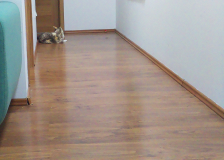

(160, 224, 3)
224 160
dataset/json_labels/frame_00924.json
size_y = 19
offset_x = 0.0
offset_y = 0.65625
Ground Truth Heatmap Shape: (40, 56)


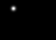

Ground Truth Heatmap Shape: (40, 56)


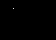

Ground Truth Heatmap Shape: (40, 56)


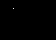

Ground Truth Heatmap Shape: (40, 56)


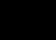

Ground Truth Heatmap Shape: (40, 56)


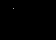

reconstruct_image_from_heatmaps



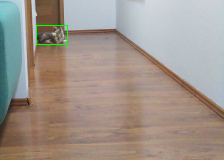

(160, 224, 3)
compared to original image 



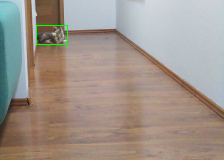

(160, 224, 3)
dataset/json_labels/frame_05684.json


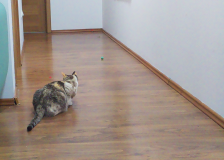

(160, 224, 3)
224 160
dataset/json_labels/frame_05684.json
size_y = 61
offset_x = 0.15625
offset_y = 0.25
Ground Truth Heatmap Shape: (40, 56)


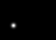

Ground Truth Heatmap Shape: (40, 56)


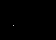

Ground Truth Heatmap Shape: (40, 56)


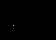

Ground Truth Heatmap Shape: (40, 56)


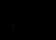

Ground Truth Heatmap Shape: (40, 56)


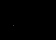

reconstruct_image_from_heatmaps



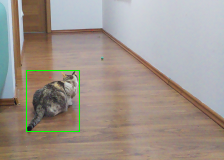

(160, 224, 3)
compared to original image 



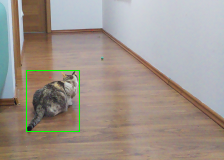

(160, 224, 3)
dataset/json_labels/frame_03593.json


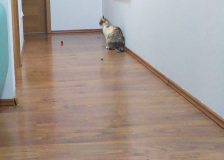

(160, 224, 3)
224 160
dataset/json_labels/frame_03593.json
size_y = 38
offset_x = 0.0625
offset_y = 0.4375
Ground Truth Heatmap Shape: (40, 56)


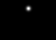

Ground Truth Heatmap Shape: (40, 56)


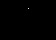

Ground Truth Heatmap Shape: (40, 56)


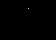

Ground Truth Heatmap Shape: (40, 56)


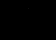

Ground Truth Heatmap Shape: (40, 56)


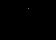

reconstruct_image_from_heatmaps



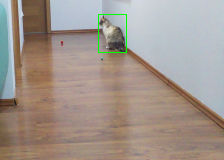

(160, 224, 3)
compared to original image 



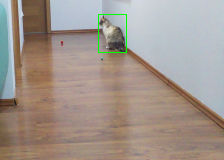

(160, 224, 3)
dataset/json_labels/frame_02855.json


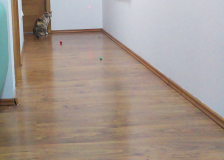

(160, 224, 3)
224 160
dataset/json_labels/frame_02855.json
size_y = 28
offset_x = 0.5625
offset_y = 0.0625
Ground Truth Heatmap Shape: (40, 56)


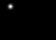

Ground Truth Heatmap Shape: (40, 56)


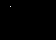

Ground Truth Heatmap Shape: (40, 56)


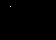

Ground Truth Heatmap Shape: (40, 56)


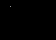

Ground Truth Heatmap Shape: (40, 56)


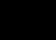

reconstruct_image_from_heatmaps



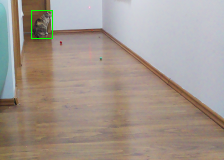

(160, 224, 3)
compared to original image 



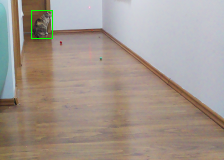

(160, 224, 3)
dataset/json_labels/frame_07939.json


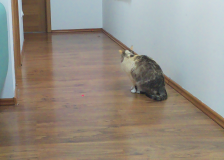

(160, 224, 3)
224 160
dataset/json_labels/frame_07939.json
size_y = 56
offset_x = 0.78125
offset_y = 0.40625
Ground Truth Heatmap Shape: (40, 56)


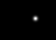

Ground Truth Heatmap Shape: (40, 56)


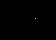

Ground Truth Heatmap Shape: (40, 56)


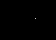

Ground Truth Heatmap Shape: (40, 56)


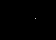

Ground Truth Heatmap Shape: (40, 56)


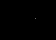

reconstruct_image_from_heatmaps



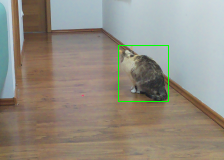

(160, 224, 3)
compared to original image 



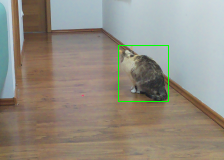

(160, 224, 3)
dataset/json_labels/frame_03587.json


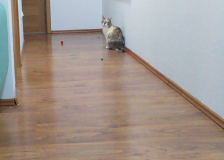

(160, 224, 3)
224 160
dataset/json_labels/frame_03587.json
size_y = 39
offset_x = 0.375
offset_y = 0.4375
Ground Truth Heatmap Shape: (40, 56)


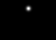

Ground Truth Heatmap Shape: (40, 56)


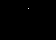

Ground Truth Heatmap Shape: (40, 56)


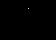

Ground Truth Heatmap Shape: (40, 56)


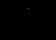

Ground Truth Heatmap Shape: (40, 56)


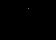

reconstruct_image_from_heatmaps



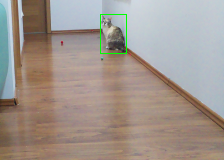

(160, 224, 3)
compared to original image 



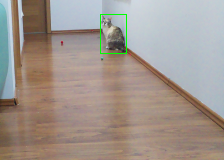

(160, 224, 3)
dataset/json_labels/frame_02841.json


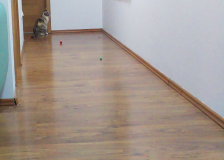

(160, 224, 3)
224 160
dataset/json_labels/frame_02841.json
size_y = 29
offset_x = 0.0625
offset_y = 0.96875
Ground Truth Heatmap Shape: (40, 56)


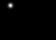

Ground Truth Heatmap Shape: (40, 56)


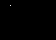

Ground Truth Heatmap Shape: (40, 56)


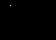

Ground Truth Heatmap Shape: (40, 56)


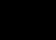

Ground Truth Heatmap Shape: (40, 56)


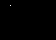

reconstruct_image_from_heatmaps



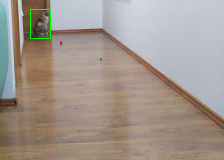

(160, 224, 3)
compared to original image 



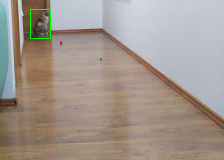

(160, 224, 3)
dataset/json_labels/frame_05848.json


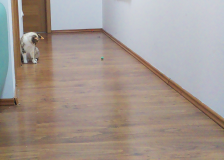

(160, 224, 3)
224 160
dataset/json_labels/frame_05848.json
size_y = 33
offset_x = 0.9375
offset_y = 0.8125
Ground Truth Heatmap Shape: (40, 56)


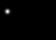

Ground Truth Heatmap Shape: (40, 56)


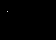

Ground Truth Heatmap Shape: (40, 56)


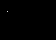

Ground Truth Heatmap Shape: (40, 56)


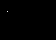

Ground Truth Heatmap Shape: (40, 56)


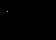

reconstruct_image_from_heatmaps



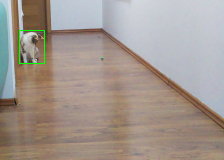

(160, 224, 3)
compared to original image 



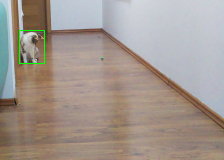

(160, 224, 3)
dataset/json_labels/frame_05690.json


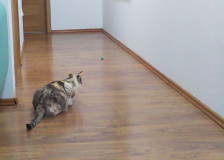

(160, 224, 3)
224 160
dataset/json_labels/frame_05690.json
size_y = 60
offset_x = 0.5625
offset_y = 0.0625
Ground Truth Heatmap Shape: (40, 56)


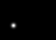

Ground Truth Heatmap Shape: (40, 56)


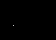

Ground Truth Heatmap Shape: (40, 56)


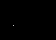

Ground Truth Heatmap Shape: (40, 56)


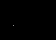

Ground Truth Heatmap Shape: (40, 56)


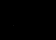

reconstruct_image_from_heatmaps



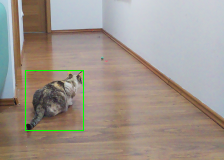

(160, 224, 3)
compared to original image 



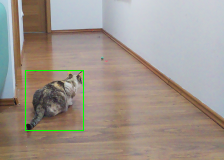

(160, 224, 3)
dataset/json_labels/frame_00930.json


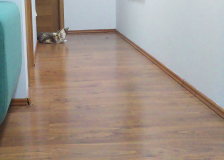

(160, 224, 3)
224 160
dataset/json_labels/frame_00930.json
size_y = 18
offset_x = 0.21875
offset_y = 0.875
Ground Truth Heatmap Shape: (40, 56)


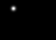

Ground Truth Heatmap Shape: (40, 56)


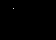

Ground Truth Heatmap Shape: (40, 56)


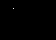

Ground Truth Heatmap Shape: (40, 56)


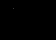

Ground Truth Heatmap Shape: (40, 56)


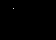

reconstruct_image_from_heatmaps



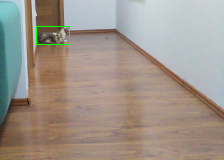

(160, 224, 3)
compared to original image 



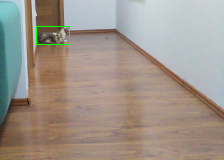

(160, 224, 3)


In [8]:

print("hello")
for image_path in image_paths_10:

    image1_resized_with_bounding_box = resize_image_with_bounding_box(image_path) #only for comparation
    image1_resized = resize_image(image_path)
    display(Image.fromarray(image1_resized))
    print(np.asarray(image1_resized).shape)
    print(image1_resized.shape[1], image1_resized.shape[0])

    #encode image
    heatmaps = generate_heatmaps(image_path, sigma=1.5)

    for heatmap in heatmaps:
        print("Ground Truth Heatmap Shape:", heatmap.shape)

        heatmap_visual = (heatmap * 255).astype(np.uint8)
        display(Image.fromarray(heatmap_visual))
    #decode
    points = decode_image(heatmaps)
    image_decoded = reconstruct_image_from_heatmaps(image1_resized, points)
    print("reconstruct_image_from_heatmaps\n")
    display(Image.fromarray(image_decoded))
    print(np.asarray(image_decoded).shape)
    print("compared to original image \n")
    display(Image.fromarray(image1_resized_with_bounding_box))
    print(np.asarray(image1_resized_with_bounding_box).shape)


